In [1]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

BATCH_SIZE = 32   # Faster training

# GPU status
!nvidia-smi


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Thu Jun 11 19:28:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |

In [2]:
from google.colab import files
print("Please select your dataset file (Final_Depression.csv)")
uploaded = files.upload()


Please select your dataset file (Final_Depression.csv)


Saving Final_Depression.csv to Final_Depression (1).csv


In [4]:
import pandas as pd

df = pd.read_csv("Final_Depression.csv", encoding='latin-1')

print(f"Rows: {len(df)}")
print(df.head())


Rows: 10000
   Label_Past(SemiSupervised)  \
0                           1   
1                           1   
2                           0   
3                           1   
4                           0   

                                                Text      Label  Depressed  \
0  The lack of this understanding is a small but ...  Depressed   0.620085   
1  i just told my parents about my depression and...  Depressed   0.990300   
2  depression is something i don't speak about ev...  Depressed   0.951788   
3  Made myself a tortilla filled with pb&j. My de...  Depressed   0.755291   
4  @WorldofOutlaws I am gonna need depression med...  Depressed   0.970960   

   NotDepressed  depression_Intensity   Average  \
0      0.001806              0.651413  0.635749   
1      0.000203              0.391696  0.690998   
2      0.073118              0.477864  0.714826   
3      0.657850              0.409744  0.582518   
4      0.000440              0.409744  0.690352   

             

In [5]:
!pip install -q transformers==4.44.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.4 MB/s eta 0:00:00


GPU: Tesla T4 | Transformers: 4.44.2 | Torch: 2.11.0+cu128
Train: 7807 | Test: 1952 | Classes: [5330 2477]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 124,696,034

STARTING TRAINING...
Epoch 1/8 | Val Acc: 0.8468
Epoch 2/8 | Val Acc: 0.8468
Epoch 3/8 | Val Acc: 0.8463
Epoch 4/8 | Val Acc: 0.8458
Epoch 5/8 | Val Acc: 0.8504
Epoch 6/8 | Val Acc: 0.8504
Epoch 7/8 | Val Acc: 0.8443
Epoch 8/8 | Val Acc: 0.8289

FINAL TEST ACCURACY: 0.8504
               precision    recall  f1-score   support

Not Depressed       0.86      0.93      0.89      1333
    Depressed       0.82      0.68      0.74       619

     accuracy                           0.85      1952
    macro avg       0.84      0.81      0.82      1952
 weighted avg       0.85      0.85      0.85      1952



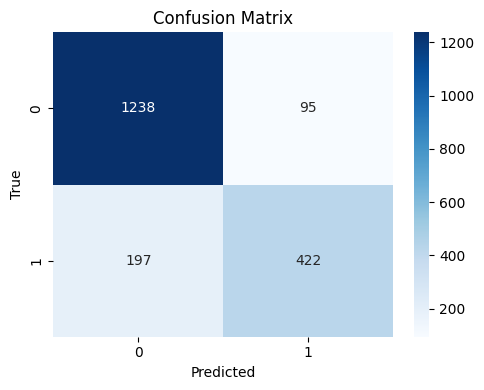

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# DUAL-INPUT ROBERTA — T4 GPU READY
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from transformers import RobertaTokenizer, RobertaModel
from torch.optim import AdamW
import shutil
from google.colab import files

# GPU CHECK
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"GPU: {torch.cuda.get_device_name(0)} | Transformers: {__import__('transformers').__version__} | Torch: {torch.__version__}")

# LOAD DATA
df = pd.read_csv("Final_Depression.csv", encoding='latin-1')
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].astype(str).str.strip().map({'Depressed': 1, 'NonDepressed': 0})
df = df.dropna(subset=['Final_Text', 'Label', 'depression_Intensity']).drop_duplicates(subset=['Final_Text'])
df['Label'] = df['Label'].astype(int)
df['depression_Intensity'] = df['depression_Intensity'].astype(float)

texts = df['Final_Text'].astype(str).tolist()
intensities = df['depression_Intensity'].values
labels = df['Label'].tolist()

# SPLIT
train_txt, test_txt, train_int, test_int, train_y, test_y = train_test_split(
    texts, intensities, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train: {len(train_txt)} | Test: {len(test_txt)} | Classes: {np.bincount(train_y)}")

# TOKENIZE
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
train_enc = tokenizer(train_txt, truncation=True, padding=True, max_length=128, return_tensors='pt')
test_enc = tokenizer(test_txt, truncation=True, padding=True, max_length=128, return_tensors='pt')

# DATALOADERS
train_loader = DataLoader(TensorDataset(
    train_enc['input_ids'], train_enc['attention_mask'],
    torch.tensor(train_int, dtype=torch.float32).unsqueeze(1),
    torch.tensor(train_y, dtype=torch.long)
), batch_size=32, shuffle=True)

test_loader = DataLoader(TensorDataset(
    test_enc['input_ids'], test_enc['attention_mask'],
    torch.tensor(test_int, dtype=torch.float32).unsqueeze(1),
    torch.tensor(test_y, dtype=torch.long)
), batch_size=32)

# MODEL
class DualRoberta(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.int_dense = nn.Linear(1, 16)
        self.classifier = nn.Sequential(
            nn.Linear(768 + 16, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 2)
        )
    def forward(self, ids, mask, intensity):
        out = self.roberta(ids, attention_mask=mask).pooler_output
        feat = torch.relu(self.int_dense(intensity))
        x = torch.cat([out, feat], dim=1)
        return self.classifier(x)

model = DualRoberta().to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# TRAIN
os.makedirs("roberta_results", exist_ok=True)
best_acc = 0

print("\nSTARTING TRAINING...")
for epoch in range(8):
    model.train()
    for batch in train_loader:
        ids, mask, intensity, labels = [x.to(device) for x in batch]
        optimizer.zero_grad()
        out = model(ids, mask, intensity)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in test_loader:
            ids, mask, intensity, labels = [x.to(device) for x in batch]
            out = model(ids, mask, intensity)
            correct += (out.argmax(1) == labels).sum().item()
    acc = correct / len(test_y)
    print(f"Epoch {epoch+1}/8 | Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'roberta_results/best_model.pth')

# FINAL EVAL
model.load_state_dict(torch.load('roberta_results/best_model.pth'))
model.eval()
pred = []
with torch.no_grad():
    for batch in test_loader:
        ids, mask, intensity, _ = [x.to(device) for x in batch]
        out = model(ids, mask, intensity)
        pred.extend(out.argmax(1).cpu().numpy())
pred = np.array(pred)

print(f"\nFINAL TEST ACCURACY: {(pred == test_y).mean():.4f}")
print(classification_report(test_y, pred, target_names=['Not Depressed', 'Depressed']))

# PLOT
cm = confusion_matrix(test_y, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('roberta_results/confusion.png')
plt.show()

# SAVE & DOWNLOAD
torch.save(model.state_dict(), 'roberta_results/model.pth')
tokenizer.save_pretrained('roberta_results/tokenizer')
shutil.make_archive('roberta_results', 'zip', 'roberta_results')
files.download('roberta_results.zip')



In [ ]:
from google.colab import files
files.download('roberta_results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
!pip install streamlit pyngrok plotly wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.6 MB/s eta 0:00:00


In [8]:
from pyngrok import ngrok
ngrok.set_auth_token("3F0NDpANe0oo9lY9tV19OKeVNwg_5qB4MVtJAPtj7EXXjwVwF")


In [9]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from transformers import RobertaTokenizer, RobertaModel

# ================================
# LOAD MODEL (same architecture)
# ================================
class DualRoberta(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.int_dense = nn.Linear(1, 16)
        self.classifier = nn.Sequential(
            nn.Linear(768 + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, ids, mask, intensity):
        out = self.roberta(ids, attention_mask=mask).pooler_output
        feat = torch.relu(self.int_dense(intensity))
        x = torch.cat([out, feat], dim=1)
        return self.classifier(x)

# ================================
# LOAD TRAINED MODEL + TOKENIZER
# ================================
tokenizer = RobertaTokenizer.from_pretrained("roberta_results/tokenizer")

model = DualRoberta()
model.load_state_dict(torch.load("roberta_results/model.pth", map_location="cpu"))
model.eval()

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("Final_Depression.csv", encoding="latin-1")
df["Label"] = df["Label"].astype(str)
df["depression_Intensity"] = df["depression_Intensity"].astype(float)
df["Final_Text"] = df["Final_Text"].astype(str)

# ================================
# DASHBOARD
# ================================
st.set_page_config(page_title="Depression Dashboard", layout="wide")
st.title("🧠 Depression Analysis Dashboard")
st.markdown("Analyze depression patterns + Live Predictions using your trained RoBERTa Model.")

# ========= METRICS ============
col1, col2, col3 = st.columns(3)
with col1:
    st.metric("Total Records", len(df))
with col2:
    st.metric("Depressed", (df["Label"]=="Depressed").sum())
with col3:
    st.metric("Non-Depressed", (df["Label"]=="NonDepressed").sum())

# ========= PIE CHART ============
st.subheader("🟪 Depression Distribution")
pie = px.pie(df, names="Label", hole=0.45)
st.plotly_chart(pie, use_container_width=True)

# ========= INTENSITY HIST ============
st.subheader("📊 Depression Intensity Histogram")
hist = px.histogram(df, x="depression_Intensity", nbins=20, color="Label")
st.plotly_chart(hist, use_container_width=True)

# ========= TEXT LENGTH ============
df["text_length"] = df["Final_Text"].str.len()
st.subheader("📏 Text Length Distribution")
length_plot = px.histogram(df, x="text_length", color="Label")
st.plotly_chart(length_plot, use_container_width=True)

# ========= WORD CLOUD ============
st.subheader("☁ Word Clouds")
col1, col2 = st.columns(2)

with col1:
    st.write("Depressed")
    text1 = " ".join(df[df["Label"]=="Depressed"]["Final_Text"])
    wc1 = WordCloud(width=600, height=400).generate(text1)
    plt.imshow(wc1)
    plt.axis("off")
    st.pyplot(plt)

with col2:
    st.write("Non-Depressed")
    text2 = " ".join(df[df["Label"]=="NonDepressed"]["Final_Text"])
    wc2 = WordCloud(width=600, height=400).generate(text2)
    plt.imshow(wc2)
    plt.axis("off")
    st.pyplot(plt)

# ========= TABLE ============
st.subheader("🔍 Explore Dataset")
choice = st.selectbox("Filter", ["All", "Depressed", "NonDepressed"])
data_to_show = df if choice == "All" else df[df["Label"] == choice]
st.dataframe(data_to_show)

# ========== LIVE PREDICTION ===========
st.header("🔮 Live Text Prediction")

text_input = st.text_area("Enter text for prediction")

if st.button("Predict"):
    if text_input.strip() == "":
        st.warning("Please enter some text.")
    else:
        encoding = tokenizer(text_input, return_tensors="pt", truncation=True, padding=True)
        ids = encoding["input_ids"]
        mask = encoding["attention_mask"]

        # default intensity (user does not provide value)
        intensity = torch.tensor([[0.5]], dtype=torch.float32)

        with torch.no_grad():
            output = model(ids, mask, intensity)
            probs = torch.softmax(output, dim=1)[0].tolist()
            pred = torch.argmax(output).item()

        label = "Depressed" if pred == 1 else "Not Depressed"

        st.subheader(f"Prediction: **{label}**")
        st.write(f"Probability - Not Depressed: {probs[0]:.4f}")
        st.write(f"Probability - Depressed: {probs[1]:.4f}")
        st.write(f"Estimated Intensity Score: {probs[1]:.4f}")


Writing dashboard.py


In [10]:
!streamlit run dashboard.py --server.port 8501 &>/content/logs.txt &


In [11]:
public_url = ngrok.connect(8501)
public_url


<NgrokTunnel: "https://kindness-lunchroom-elastic.ngrok-free.dev" -> "http://localhost:8501">

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import torch
from transformers import RobertaTokenizer, RobertaModel
import torch.nn as nn

device = torch.device("cpu")  # FORCE CPU

st.set_page_config(page_title="Depression Dashboard", layout="wide")

class DualRoberta(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.int_dense = nn.Linear(1, 16)
        self.classifier = nn.Sequential(
            nn.Linear(768 + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, ids, mask, intensity):
        out = self.roberta(ids, attention_mask=mask).pooler_output
        feat = torch.relu(self.int_dense(intensity))
        x = torch.cat([out, feat], dim=1)
        return self.classifier(x)

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

model = DualRoberta().to(device)
model.load_state_dict(torch.load("roberta_results/model.pth", map_location=device))
model.eval()

df = pd.read_csv("Final_Depression.csv", encoding="latin-1")

df["Label"] = df["Label"].astype(str)
df["depression_Intensity"] = df["depression_Intensity"].astype(float)
df["Final_Text"] = df["Final_Text"].astype(str)

st.title("🧠 Depression Analysis Dashboard")

col1, col2, col3 = st.columns(3)
with col1:
    st.metric("Total Records", len(df))
with col2:
    st.metric("Depressed", (df["Label"] == "Depressed").sum())
with col3:
    st.metric("Non-Depressed", (df["Label"] == "NonDepressed").sum())

st.subheader("🟪 Depression Distribution")
pie = px.pie(df, names="Label", title="Depression Distribution", hole=0.45)
st.plotly_chart(pie, use_container_width=True)

st.subheader("📊 Depression Intensity Histogram")
hist = px.histogram(df, x="depression_Intensity", nbins=20, color="Label")
st.plotly_chart(hist, use_container_width=True)

df["text_length"] = df["Final_Text"].str.len()
st.subheader("📏 Text Length Distribution")
length_plot = px.histogram(df, x="text_length", color="Label")
st.plotly_chart(length_plot, use_container_width=True)

st.subheader("☁ Word Clouds")

col1, col2 = st.columns(2)
with col1:
    st.write("Depressed")
    text1 = " ".join(df[df["Label"] == "Depressed"]["Final_Text"])
    wc1 = WordCloud(width=500, height=350).generate(text1)
    plt.imshow(wc1)
    plt.axis("off")
    st.pyplot(plt)
with col2:
    st.write("Non-Depressed")
    text2 = " ".join(df[df["Label"] == "NonDepressed"]["Final_Text"])
    wc2 = WordCloud(width=500, height=350).generate(text2)
    plt.imshow(wc2)
    plt.axis("off")
    st.pyplot(plt)

st.subheader("🔍 Explore Data")
choice = st.selectbox("Filter", ["All", "Depressed", "NonDepressed"])
data_to_show = df if choice == "All" else df[df["Label"] == choice]
st.dataframe(data_to_show)

st.header("🔮 Live Prediction")

text = st.text_area("Enter text")
if st.button("Predict"):
    enc = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    ids = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)
    intensity = torch.tensor([[0.5]], dtype=torch.float32).to(device)

    with torch.no_grad():
        output = model(ids, mask, intensity)
        probs = torch.softmax(output, dim=1)[0].tolist()
        pred = torch.argmax(output).item()

    label = "Depressed" if pred == 1 else "Not Depressed"
    st.subheader(f"Prediction: {label}")
    st.write("Not Depressed:", probs[0])
    st.write("Depressed:", probs[1])


2025-11-17 06:42:52.862 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


FileNotFoundError: [Errno 2] No such file or directory: 'roberta_results/model.pth'

In [ ]:
!unzip -o roberta_results.zip


unzip:  cannot find or open roberta_results.zip, roberta_results.zip.zip or roberta_results.zip.ZIP.
